In [1]:
import pandas as pd
import json
import re
import os
import torch
import spacy
from torch import nn
from transformers import BertModel, BertConfig, BertTokenizer, BertForSequenceClassification
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from torch.nn.functional import softmax
import nltk
# Download & load NLTK names
nltk.download('names')
from nltk.corpus import names

pd.set_option("display.max_columns", None)  # Ensures all columns are shown
pd.set_option("display.max_rows", None)  # Shows all rows if needed

C:\Users\PC_LOCAL\AppData\Roaming\Python\Python310\site-packages\torchvision\datapoints\__init__.py:12: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submit any feedback you may have in this issue: https://github.com/pytorch/vision/issues/6753, and you can also check out https://github.com/pytorch/vision/issues/7319 to learn more about the APIs that we suspect might involve future changes. You can silence this warning by calling torchvision.disable_beta_transforms_warning().
  warnings.warn(_BETA_TRANSFORMS_WARNING)
C:\Users\PC_LOCAL\AppData\Roaming\Python\Python310\site-packages\torchvision\transforms\v2\__init__.py:54: UserWarning: The torchvision.datapoints and torchvision.transforms.v2 namespaces are still Beta. While we do not expect major breaking changes, some APIs may still change according to user feedback. Please submi

In [2]:
from sklearn.model_selection import train_test_split
import json
import pandas as pd
import re

# Load the dataset
dataset_number = 1
with open(f'./Datasets/dataset_{dataset_number}_train.json') as file:
    raw_ds = json.load(file)

# Flatten JSON to DataFrame
train_df = pd.json_normalize(raw_ds)

# Step 1: Flatten JSON-like fields
def flatten_field(field):
    if isinstance(field, list):
        return ";".join(map(str, field))
    elif isinstance(field, dict):
        return json.dumps(field)
    return field

for col in train_df.columns:
    train_df[col] = train_df[col].apply(flatten_field)

# Step 2: Clean text fields and remove IP in `request.headers.Host`
def clean_text(text, column_name=None):
    if not isinstance(text, str):
        return text
    # Remove dangerous patterns, extra spaces, and non-alphanumeric characters
    text = re.sub(r'\${.*?}', '', text)  # Remove Log4j-style payloads
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    
    # Remove IP address in 'request.headers.Host' but keep the port
    if column_name == "request.headers.Host":
        text = re.sub(r'^\d{1,3}(\.\d{1,3}){3}', '', text).strip(":")
    return text

for col in train_df.columns:
    if train_df[col].dtype == "object":
        train_df[col] = train_df[col].apply(lambda x: clean_text(x, column_name=col))

# Step 3: Drop irrelevant columns
irrelevant_columns = [
    "request.headers.Date",  # Irrelevant for payload detection
    "response.status_code",  # Similar info already in `response.status`
]
train_df.drop(columns=irrelevant_columns, inplace=True, errors="ignore")

# Step 4: Ensure labels and payload text
if 'request.Attack_Tag' in train_df.columns:
    train_df.rename(columns={"request.Attack_Tag": "label"}, inplace=True)
if 'request.url' in train_df.columns:
    train_df.rename(columns={"request.url": "payload"}, inplace=True)

if 'label' in train_df.columns:
    train_df['label'].fillna("benign", inplace=True)

# ✅ Step 5: Split Data into Train and Validation Sets (80-20 Split)
train_df, val_df = train_test_split(train_df, test_size=0.2, random_state=42)

# Reset index
train_df.reset_index(drop=True, inplace=True)
val_df.reset_index(drop=True, inplace=True)

# ✅ Preview the Data Splits
print(f"✅ Training Set: {train_df.shape}")
print(f"✅ Validation Set: {val_df.shape}")

print("\nTrain Data Sample:")
print(train_df.head())

print("\nValidation Data Sample:")
print(val_df.head())


✅ Training Set: (3425, 23)
✅ Validation Set: (857, 23)

Train Data Sample:
  request.headers.Host                         request.headers.User-Agent  \
0                 5000  mozilla/5.0 (x11; openbsd i386) applewebkit/53...   
1                 5000  mozilla/5.0 (macintosh; intel mac os x 10_10; ...   
2                 5000  mozilla/5.0 (windows nt 6.1; wow64) applewebki...   
3                 5000  mozilla/5.0 (windows nt 5.1) applewebkit/537.3...   
4                 5000  mozilla/5.0 (windows nt 6.4; wow64) applewebki...   

  request.headers.Accept-Encoding request.headers.Accept  \
0               gzip, deflate, br                    */*   
1               gzip, deflate, br                    */*   
2               gzip, deflate, br                    */*   
3               gzip, deflate, br                    */*   
4               gzip, deflate, br                    */*   

  request.headers.Connection request.headers.Accept-Language  \
0                 keep-alive         

C:\Users\PC_LOCAL\AppData\Local\Temp\ipykernel_1968\2690199787.py:57: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  train_df['label'].fillna("benign", inplace=True)


In [3]:
unique_labels = train_df['label'].unique()
unique_labels

array(['sql injection', 'benign', 'cookie injection', 'log4j',
       'directory traversal', 'rce', 'log forging'], dtype=object)

In [4]:

# # Load the dataset
# dataset_number = 1
# with open(f'./Datasets/dataset_{dataset_number}_val.json') as file:
#     raw_ds = json.load(file)

# # Flatten JSON to DataFrame
# val_df = pd.json_normalize(raw_ds)

# # Step 1: Flatten JSON-like fields
# def flatten_field(field):
#     if isinstance(field, list):
#         return ";".join(map(str, field))
#     elif isinstance(field, dict):
#         return json.dumps(field)
#     return field

# for col in val_df.columns:
#     val_df[col] = val_df[col].apply(flatten_field)

# # Step 2: Clean text fields and remove IP in `request.headers.Host`
# def clean_text(text, column_name=None):
#     if not isinstance(text, str):
#         return text
#     # Remove dangerous patterns, extra spaces, and non-alphanumeric characters
#     text = re.sub(r'\${.*?}', '', text)  # Remove Log4j-style payloads
#     text = re.sub(r'\s+', ' ', text).strip()
#     text = text.lower()
    
#     # Remove IP address in 'request.headers.Host' but keep the port
#     if column_name == "request.headers.Host":
#         text = re.sub(r'^\d{1,3}(\.\d{1,3}){3}', '', text).strip(":")
#     return text

# for col in val_df.columns:
#     if val_df[col].dtype == "object":
#         val_df[col] = val_df[col].apply(lambda x: clean_text(x, column_name=col))

# # Step 3: Drop irrelevant columns
# irrelevant_columns = [
#     "request.headers.Date",  # Irrelevant for payload detection
#     "response.status_code",  # Similar info already in `response.status`
# ]
# val_df.drop(columns=irrelevant_columns, inplace=True, errors="ignore")

# # Step 4: Ensure labels and payload text
# if 'request.Attack_Tag' in val_df.columns:
#     val_df.rename(columns={"request.Attack_Tag": "label"}, inplace=True)
# if 'request.url' in val_df.columns:
#     val_df.rename(columns={"request.url": "payload"}, inplace=True)

# if 'label' in val_df.columns:
#         val_df['label'].fillna("benign", inplace=True)

# # Preview the modified DataFrame
# print("\nModified DataFrame Preview:")
# val_df.head()


In [5]:
# Modify clean_text function to remove local URL prefix in 'payload' column
def clean_text(text, column_name=None):
    if not isinstance(text, str):
        return text
    # Remove dangerous patterns, extra spaces, and non-alphanumeric characters
    text = re.sub(r'\${.*?}', '', text)  # Remove Log4j-style payloads
    text = re.sub(r'\s+', ' ', text).strip()
    text = text.lower()
    
    # Remove IP address in 'request.headers.Host' but keep the port
    if column_name == "request.headers.Host":
        text = re.sub(r'^\d{1,3}(\.\d{1,3}){3}', '', text).strip(":")
    
    # Remove 'http://127.0.0.1:5000/' from 'payload' column
    if column_name == "payload":
        text = re.sub(r'^http://127\.0\.0\.1:5000/', '', text)

    return text

# Apply the updated function to clean relevant columns
for col in val_df.columns:
    if val_df[col].dtype == "object":
        val_df[col] = val_df[col].apply(lambda x: clean_text(x, column_name=col))

val_df.head()


,request.headers.Host,request.headers.User-Agent,request.headers.Accept-Encoding,request.headers.Accept,request.headers.Connection,request.headers.Accept-Language,request.headers.Sec-Fetch-Site,request.headers.Sec-Fetch-Mode,request.headers.Sec-Fetch-User,request.headers.Sec-Fetch-Dest,request.headers.Set-Cookie,request.method,payload,request.body,label,response.status,response.headers.Content-Type,response.headers.Content-Length,response.body,request.headers.Cookie,response.headers.Location,request.headers.Content-Length,response.headers.Set-Cookie
0,5000,mozilla/5.0 (windows nt 6.4; wow64) applewebki...,"gzip, deflate, br",*/*,keep-alive,de,none,same-origin,?1,document,['ck=-8wpqirrdzeknu8pp6_lyobl_1wfaswxneoe_lucb...,get,orders/check/exists/3476,,benign,404 not found,text/html; charset=utf-8,207,<!doctype html> <html lang=en> <title>404 not ...,NaN,NaN,NaN,NaN
1,5000,mozilla/5.0 (windows nt 6.1; wow64; rv:40.0) g...,"gzip, deflate, br",*/*,keep-alive,de,none,same-origin,?1,document,['ck=inr2mtbus7vz-yvxrkiyiqxvepo5_uifw21oqdn5e...,get,categories/check/number/7664,,benign,404 not found,application/json,43,"{""error"": ""category number not found""}",NaN,NaN,NaN,NaN
2,5000,mozilla/5.0 (windows nt 6.1; wow64) applewebki...,"gzip, deflate, br",*/*,keep-alive,de,none,same-origin,?1,document,['ck=zqv5dy8lwcfk7emzncz2y4babhytrzcyjx5vde-yk...,get,greet/2401,,benign,200 ok,text/html; charset=utf-8,20,<h2>hello 2401!</h2>,NaN,NaN,NaN,NaN
3,5000,mozilla/5.0 (x11; linux x86_64) applewebkit/53...,"gzip, deflate, br",*/*,keep-alive,de-ch,none,same-origin,?1,document,['ck=zbghi9kzy8njf-tjv3_ibtwrcqmaqkhrzp4awn1pp...,get,categories/check/all,,log4j,200 ok,application/json,1112,"[{""category_id"": ""1"", ""category_name"": ""bevera...",NaN,NaN,NaN,NaN
4,5000,mozilla/5.0 (windows nt 6.1; wow64; rv:31.0) g...,"gzip, deflate, br",*/*,keep-alive,"en-us,en;q=0.5",none,same-origin,?1,document,['ck=bckl5jn55yqjwhcsad7tfe7qzwheijpl7cyxquu5n...,post,cookielogin,,cookie injection,302 found,text/html; charset=utf-8,211,<!doctype html> <html lang=en> <title>redirect...,username=gasvyqaaaaaaaacmcgj1awx0aw5zliwezxzhb...,/cookielogin,0,username=gasvkgaaaaaaaacmcf9fbwfpbl9fliwgugvyc...


In [6]:
for col in train_df.columns:
    if train_df[col].dtype == "object":
        train_df[col] = train_df[col].apply(lambda x: clean_text(x, column_name=col))

train_df.head()

,request.headers.Host,request.headers.User-Agent,request.headers.Accept-Encoding,request.headers.Accept,request.headers.Connection,request.headers.Accept-Language,request.headers.Sec-Fetch-Site,request.headers.Sec-Fetch-Mode,request.headers.Sec-Fetch-User,request.headers.Sec-Fetch-Dest,request.headers.Set-Cookie,request.method,payload,request.body,label,response.status,response.headers.Content-Type,response.headers.Content-Length,response.body,request.headers.Cookie,response.headers.Location,request.headers.Content-Length,response.headers.Set-Cookie
0,5000,mozilla/5.0 (x11; openbsd i386) applewebkit/53...,"gzip, deflate, br",*/*,keep-alive,"en-us,en;q=0.9,he;q=0.8",none,websocket,?1,document,['ck=tpd_ivu2wcpiai6wutgl_dwywi37h4kubtaeo1_ss...,get,login/user?username=christopher&password=carlt...,,sql injection,401 unauthorized,application/json,31,"{""error"": ""access denied""}",NaN,NaN,NaN,NaN
1,5000,mozilla/5.0 (macintosh; intel mac os x 10_10; ...,"gzip, deflate, br",*/*,keep-alive,"en-us,en;q=0.5",none,same-origin,?1,document,['ck=x9c0acjnlftdokmseemjm6fbwmqe6-2h2-fys55q1...,get,login/user?username=martin&password=jessicawil...,,sql injection,401 unauthorized,application/json,31,"{""error"": ""access denied""}",NaN,NaN,NaN,NaN
2,5000,mozilla/5.0 (windows nt 6.1; wow64) applewebki...,"gzip, deflate, br",*/*,keep-alive,de-ch,none,same-origin,?1,document,['ck=aemh0nebund_qrqklkyitfotcfiajwlfjqlbfrgyp...,get,static/download_txt/10200,,benign,200 ok,application/json,38,"{""error"": ""file 10200 not found""}",NaN,NaN,NaN,NaN
3,5000,mozilla/5.0 (windows nt 5.1) applewebkit/537.3...,"gzip, deflate, br",*/*,keep-alive,de-ch,none,same-origin,?1,document,['ck=x8388idzag7jtdqd_hvrwc5yqg9z0aqva4mc761pk...,get,,,benign,200 ok,text/html; charset=utf-8,34,"this is the home route, welcome :)",NaN,NaN,NaN,NaN
4,5000,mozilla/5.0 (windows nt 6.4; wow64) applewebki...,"gzip, deflate, br",*/*,keep-alive,"en-us,en;q=0.5",none,same-origin,?1,document,['ck=eg1w8d0t3ti3c0i97_nsu4e6sw8jkybklnqvi8zyf...,get,orders/check/exists/1499,,benign,404 not found,text/html; charset=utf-8,207,<!doctype html> <html lang=en> <title>404 not ...,NaN,NaN,NaN,NaN


In [7]:
# Check dataset statistics after cleaning
print("\nDataset Info After Preprocessing:")
train_df.info()


Dataset Info After Preprocessing:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3425 entries, 0 to 3424
Data columns (total 23 columns):
 #   Column                           Non-Null Count  Dtype 
---  ------                           --------------  ----- 
 0   request.headers.Host             3425 non-null   object
 1   request.headers.User-Agent       3425 non-null   object
 2   request.headers.Accept-Encoding  3425 non-null   object
 3   request.headers.Accept           3425 non-null   object
 4   request.headers.Connection       3425 non-null   object
 5   request.headers.Accept-Language  3425 non-null   object
 6   request.headers.Sec-Fetch-Site   3425 non-null   object
 7   request.headers.Sec-Fetch-Mode   3425 non-null   object
 8   request.headers.Sec-Fetch-User   3425 non-null   object
 9   request.headers.Sec-Fetch-Dest   3425 non-null   object
 10  request.headers.Set-Cookie       3425 non-null   object
 11  request.method                   3425 non-null   object
 12 

In [8]:
train_df.describe(include='all')

,request.headers.Host,request.headers.User-Agent,request.headers.Accept-Encoding,request.headers.Accept,request.headers.Connection,request.headers.Accept-Language,request.headers.Sec-Fetch-Site,request.headers.Sec-Fetch-Mode,request.headers.Sec-Fetch-User,request.headers.Sec-Fetch-Dest,request.headers.Set-Cookie,request.method,payload,request.body,label,response.status,response.headers.Content-Type,response.headers.Content-Length,response.body,request.headers.Cookie,response.headers.Location,request.headers.Content-Length,response.headers.Set-Cookie
count,3425,3425,3425,3425,3425,3425,3425,3425,3425,3425,3425,3425,3425,3425,3425,3425,3425,3425,3425,446,323,247,247
unique,1,33,1,1,1,4,1,2,1,1,3425,2,2018,1,7,5,2,91,269,38,2,1,1
top,5000,mozilla/5.0 (windows nt 6.1; rv:27.3) gecko/20...,"gzip, deflate, br",*/*,keep-alive,"en-us,en;q=0.9,he;q=0.8",none,websocket,?1,document,['ck=tpd_ivu2wcpiai6wutgl_dwywi37h4kubtaeo1_ss...,get,cookielogin,,benign,200 ok,application/json,207,<!doctype html> <html lang=en> <title>404 not ...,username=gasvzgaaaaaaaacmcgj1awx0aw5zliwezxzhb...,/cookielogin,0,username=gasvkgaaaaaaaacmcf9fbwfpbl9fliwgugvyc...
freq,3425,130,3425,3425,3425,870,3425,1738,3425,3425,1,3178,446,3425,1644,1565,1927,353,353,29,247,247,247


In [9]:
# Ensure only 'payload' and 'label' exist in train_df and val_df
required_columns = ["payload", "label"]

# For training data
if not all(col in train_df.columns for col in required_columns):
    raise ValueError("train_df must contain 'payload' and 'label' columns.")
train_df = train_df[required_columns]  # Keep only payload & label

if not all(col in val_df.columns for col in required_columns):
    raise ValueError("val_df must contain 'payload' and 'label' columns.")
val_df = val_df[required_columns]  # Keep only payload & label

# Print confirmation
print(f"✅ train_df columns: {list(train_df.columns)}")
print(f"✅ val_df columns: {list(val_df.columns)}")


✅ train_df columns: ['payload', 'label']
✅ val_df columns: ['payload', 'label']


In [10]:


# Initialize the BERT tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

# Ensure the DataFrame has 'payload' and 'label' columns
if "payload" not in train_df.columns or "label" not in train_df.columns:
    raise ValueError("The DataFrame must contain 'payload' and 'label' columns.")

# Step 1: Preprocess the payload column to remove IPs
def remove_ip_from_payload(payload):
    if not isinstance(payload, str):
        return payload
    # Remove IP addresses but keep the port
    return re.sub(r'\b\d{1,3}(\.\d{1,3}){3}', '', payload).strip(":/")

train_df["payload"] = train_df["payload"].apply(remove_ip_from_payload)

# Step 2: Tokenize the payload texts and match with labels
tokenized_data = []
for _, row in train_df.iterrows():
    payload = row.get("payload")
    label = row.get("label")
    if pd.notnull(payload) and pd.notnull(label):
        tokens = tokenizer.tokenize(payload)  # Tokenize the cleaned payload
        tokenized_data.append({"tokens": tokens, "label": label})  # Add tokens and label

# Save the tokenized data into a `.dic` file format
output_file = './Datasets/tokenized_payloads.dic'
with open(output_file, 'w', encoding='utf-8') as outfile:
    json.dump(tokenized_data, outfile, ensure_ascii=False, indent=4)

# Print a preview of the tokenized data
print("\nTokenized Data Example:")
for example in tokenized_data[:5]:  # Show first 5 examples for clarity
    print(f"Tokens: {example['tokens']}")
    print(f"Label: {example['label']}\n")



Tokenized Data Example:
Tokens: ['log', '##in', '/', 'user', '?', 'user', '##name', '=', 'christopher', '&', 'password', '=', 'carlton', '##wil', '##lard', "'", '%', '20', '##or', '%', '20', "'", 'joseph', '##de', '##mos', '##s', "'", '=', "'", 'joseph', '##de', '##mos', '##s']
Label: sql injection

Tokens: ['log', '##in', '/', 'user', '?', 'user', '##name', '=', 'martin', '&', 'password', '=', 'jessica', '##wil', '##son', "'", '%', '20', '##or', '%', '20', "'", 'michael', '##lar', '##ge', "'", '=', "'", 'michael', '##lar', '##ge']
Label: sql injection

Tokens: ['static', '/', 'download', '_', 'tx', '##t', '/', '102', '##00']
Label: benign

Tokens: []
Label: benign

Tokens: ['orders', '/', 'check', '/', 'exists', '/', '149', '##9']
Label: benign



In [11]:
# 🔹 Step 1: Load NLP Models
nlp = spacy.load("en_core_web_sm")  # Load spaCy for dynamic name detection
nltk.download('names')
known_names = set(name.lower() for name in names.words())  # Load predefined names from NLTK in lowercase

# 🔹 Step 2: Load Dataset
if "payload" not in train_df.columns:
    raise ValueError("The DataFrame must contain a 'payload' column.")

# 🔹 Step 3: Initialize `word2id.json`
word2id_file = "./Datasets/word2id.json"

word2id = {}  # Create new file if it doesn’t exist

# 🔹 Step 4: Initialize Tokenizer
tokenizer = BertTokenizer.from_pretrained("bert-large-cased")

# 🔹 Step 5: Tokenize and Detect Names **Dynamically**
def tokenize_with_name_detection(text):
    """
    Tokenizes text while dynamically detecting if a token is a name.
    Ensures detected names get ID `1` in `word2id.json`.
    """
    if not isinstance(text, str):
        return [], set()

    tokens = tokenizer.tokenize(text)  # Tokenize payload
    detected_names = set()

    # Use spaCy to detect names in the original text
    for token in tokens:
        lower_token = token.lower()
        doc = nlp(lower_token)
        for ent in doc.ents:
            if ent.label_ == "PERSON":  # If the entity is a person's name
                detected_names.add(ent.text.lower())  # Store names in lowercase

    # Additionally, check if a token appears to be a name
    for token in tokens:
        lower_token = token.lower()
        if lower_token in known_names or lower_token in detected_names:  # Match dynamically detected names
            detected_names.add(lower_token)  # Store detected names in lowercase

    return tokens, detected_names

# 🔹 Step 6: Process Dataset for Tokenization & Name Detection
tokens_list = []
all_detected_names = set()

for payload in train_df["payload"].dropna():
    tokens, detected_names = tokenize_with_name_detection(payload)
    tokens_list.extend(tokens)  # Collect all tokens
    all_detected_names.update(detected_names)  # Store detected names

# 🔹 Step 7: Preserve Existing Assignments and Generate Unique IDs
existing_tokens = set(word2id.keys())  # Store existing tokens
current_id = max(word2id.values(), default=1) + 1  # Start numbering after max existing ID

# 🔹 Ensure all dynamically detected names get ID `1`
for name in all_detected_names:
    name = name.lower()  # Convert to lowercase
    if name not in word2id:  # If not already assigned, mark as `1`
        word2id[name] = 1

# 🔹 Assign unique IDs to new tokens only if they are not already in `word2id`
unique_tokens = sorted(set(tokens_list))
for token in unique_tokens:
    token = token.lower()  # Ensure consistent lowercase
    if token not in word2id:  # Avoid duplicate tokens
        word2id[token] = current_id
        current_id += 1

# 🔹 Step 8: Save Updated `word2id.json`
os.makedirs(os.path.dirname(word2id_file), exist_ok=True)
with open(word2id_file, "w", encoding="utf-8") as outfile:
    json.dump(word2id, outfile, ensure_ascii=False, indent=4)

# 🔹 Print Preview of `word2id.json`
print("\nWord-to-ID Mapping Example:")
for word, index in list(word2id.items())[:20]:  # Show first 20 mappings
    print(f"{word}: {index}")

print(f"\nUpdated word-to-ID mapping saved to {word2id_file}")


[nltk_data] Downloading package names to
[nltk_data]     C:\Users\PC_LOCAL\AppData\Roaming\nltk_data...
[nltk_data]   Package names is already up-to-date!



Word-to-ID Mapping Example:
lder: 1
al: 1
gno: 1
ryl: 1
zel: 1
ia: 1
smith: 1
beth: 1
las: 1
wart: 1
mona: 1
lle: 1
tan: 1
will: 1
ris: 1
gan: 1
bert: 1
hil: 1
mark: 1
ball: 1

Updated word-to-ID mapping saved to ./Datasets/word2id.json


In [12]:
# Load word2id mapping
word2id_path = "./Datasets/word2id.json"
with open(word2id_path, "r", encoding="utf-8") as f:
    word2id = json.load(f)

# Create a new vocabulary list
vocab_set = set()  # Using a set to ensure `[NAME]` appears only once

for word, index in word2id.items():
    if index == 1:  # If the word is a name (ID = 1), replace with [NAME]
        vocab_set.add("[NAME]")
    else:
        vocab_set.add(word)

# Convert set to sorted list to maintain order
sorted_vocab = sorted(vocab_set)

# Save as `vocab.txt`
vocab_file_path = "./Datasets/vocab.txt"
with open(vocab_file_path, "w", encoding="utf-8") as f:
    for word in sorted_vocab:
        f.write(word + "\n")  # Write each word on a new line

print(f"✅ Custom vocab file saved at: {vocab_file_path}")

tokenizer = BertTokenizer(vocab_file=vocab_file_path, do_lower_case=False, unk_token='[UNK]', sep_token='[SEP]',
                          pad_token='[PAD]', cls_token='[CLS]', mask_token='[MASK]')


✅ Custom vocab file saved at: ./Datasets/vocab.txt


In [13]:

config = BertConfig(
    vocab_size=len(tokenizer),
    hidden_size=144,  # Ensure divisible by num_attention_heads
    num_hidden_layers=12,
    num_attention_heads=12,
    intermediate_size=512,
    hidden_act="gelu",
    hidden_dropout_prob=0.1,
    attention_probs_dropout_prob=0.1,
    max_position_embeddings=512,
    type_vocab_size=2,
    initializer_range=0.02
)



class BERTClassifier(nn.Module):
    def __init__(self, config, num_classes):
        super(BERTClassifier, self).__init__()
        self.config = config  # Store config
        self.bert = BertModel(config)
        self.classifier = nn.Linear(config.hidden_size, num_classes)

    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        pooled_output = outputs.pooler_output
        return self.classifier(pooled_output)

    # ✅ Add method to save in Hugging Face format
    def save_pretrained(self, save_directory):
        """Save model and configuration."""
        import os
        os.makedirs(save_directory, exist_ok=True)
        
        # Save model weights
        torch.save(self.state_dict(), f"{save_directory}/pytorch_model.bin")
        
        # Save config
        self.config.save_pretrained(save_directory)

    # ✅ Add method to load the model
    @classmethod
    def from_pretrained(cls, load_directory, num_classes):
        """Load model and configuration."""
        config = BertConfig.from_pretrained(load_directory)  # Load config
        model = cls(config, num_classes)  # Initialize model
        model.load_state_dict(torch.load(f"{load_directory}/pytorch_model.bin"))  # Load weights
        return model



In [14]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.optim import Adam
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from transformers import BertTokenizer, BertModel, BertConfig

# Device Setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Load Tokenizer & Configuration
vocab_file_path = "./Datasets/vocab.txt"
tokenizer = BertTokenizer(vocab_file=vocab_file_path, do_lower_case=False)
config = BertConfig.from_pretrained("bert-base-uncased")

# Define Fine-grained Co-Attention Mechanism
class FineGrainedCoAttention(nn.Module):
    def __init__(self, hidden_size):
        super(FineGrainedCoAttention, self).__init__()
        self.Wq = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wk = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wv = nn.Linear(hidden_size, hidden_size, bias=False)
        self.Wf = nn.Linear(hidden_size * 2, hidden_size)
        self.softmax = nn.Softmax(dim=-1)
    
    def forward(self, query, context):
        Q = self.Wq(query)  # (batch, hidden_size)
        K = self.Wk(context)  # (batch, seq_len, hidden_size)
        V = self.Wv(context)  # (batch, seq_len, hidden_size)
        
        attention_scores = torch.bmm(K, Q.unsqueeze(2)).squeeze(2)  # (batch, seq_len)
        attention_weights = self.softmax(attention_scores)  # (batch, seq_len)
        attended_rep = torch.bmm(attention_weights.unsqueeze(1), V).squeeze(1)  # (batch, hidden_size)
        
        fine_grained_output = torch.tanh(self.Wf(torch.cat((attended_rep, query), dim=-1)))
        
        return fine_grained_output

# Define the BERT Model with Fine-grained Co-Attention
class BERTFineGrainedCoAttentionClassifier(nn.Module):
    def __init__(self, config, num_classes):
        super(BERTFineGrainedCoAttentionClassifier, self).__init__()
        self.bert = BertModel(config)
        self.co_attention = FineGrainedCoAttention(config.hidden_size)
        self.classifier = nn.Linear(config.hidden_size, num_classes)
    
    def forward(self, input_ids, attention_mask=None, token_type_ids=None):
        outputs = self.bert(input_ids, attention_mask=attention_mask, token_type_ids=token_type_ids)
        sequence_output = outputs.last_hidden_state  # (batch, seq_len, hidden_size)
        pooled_output = outputs.pooler_output  # (batch, hidden_size)
        
        co_attention_output = self.co_attention(pooled_output, sequence_output)  # Enhanced representation
        logits = self.classifier(co_attention_output)  # Classification head
        
        return logits
    
    def save_pretrained(self, save_directory):
        os.makedirs(save_directory, exist_ok=True)
        torch.save(self.state_dict(), os.path.join(save_directory, "pytorch_model.bin"))
        config.save_pretrained(save_directory)
    
    @classmethod
    def from_pretrained(cls, load_directory, num_classes):
        config = BertConfig.from_pretrained(load_directory)
        model = cls(config, num_classes)
        model.load_state_dict(torch.load(os.path.join(load_directory, "pytorch_model.bin")))
        return model

# Initialize Model
num_classes = 7
model = BERTFineGrainedCoAttentionClassifier(config, num_classes).to(device)

# Load Training Data
train_df
label_mapping = {
    "benign": 0,
    "sql injection": 1,
    "cookie injection": 2,
    "directory traversal": 3,
    "log4j": 4,
    "log forging": 5,
    "rce": 6,
}
train_df["label_id"] = train_df["label"].map(label_mapping)

# Tokenize Input Data
max_len = 128
input_ids, attention_masks = [], []
labels = train_df["label_id"].values

for text in train_df["payload"]:
    encoded_input = tokenizer.encode_plus(
        text, add_special_tokens=True, max_length=max_len,
        padding="max_length", truncation=True, return_tensors="pt"
    )
    input_ids.append(encoded_input["input_ids"].squeeze(0))
    attention_masks.append(encoded_input["attention_mask"].squeeze(0))

# Convert to Tensor
input_ids = torch.stack(input_ids).to(device)
attention_masks = torch.stack(attention_masks).to(device)
labels = torch.tensor(labels).to(device)

# Class Balancing
class_counts = train_df["label_id"].value_counts().sort_index().tolist()
class_weights = 1. / torch.tensor(class_counts, dtype=torch.float, device=device)
sample_weights = class_weights[labels]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

# Create Dataset & DataLoader
dataset = TensorDataset(input_ids, attention_masks, labels)
dataloader = DataLoader(dataset, sampler=sampler, batch_size=8)

# Loss & Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = Adam(model.parameters(), lr=3e-5)

# Training Loop
epochs = 10
model.train()

for epoch in range(epochs):
    total_loss = 0
    for batch in dataloader:
        input_ids_batch, attention_mask_batch, labels_batch = batch
        optimizer.zero_grad()
        
        # Forward pass
        logits = model(input_ids=input_ids_batch, attention_mask=attention_mask_batch)
        loss = criterion(logits, labels_batch)
        
        # Backward pass
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
    
    print(f"Epoch {epoch+1}/{epochs}, Loss: {total_loss / len(dataloader)}")

# Save the Model
model.save_pretrained("./finegrained_coattention_bert_model")
tokenizer.save_pretrained("./finegrained_coattention_bert_model")


Epoch 1/10, Loss: 0.30325958963227406
Epoch 2/10, Loss: 0.2193815589416772
Epoch 3/10, Loss: 0.20419180337426476
Epoch 4/10, Loss: 0.214314895202536
Epoch 5/10, Loss: 0.20431670581591957
Epoch 6/10, Loss: 0.19740878746533844
Epoch 7/10, Loss: 0.1958987615306985
Epoch 8/10, Loss: 0.19796015836659311
Epoch 9/10, Loss: 0.30376821412154154
Epoch 10/10, Loss: 0.19848389802693275


('./finegrained_coattention_bert_model\\tokenizer_config.json',
 './finegrained_coattention_bert_model\\special_tokens_map.json',
 './finegrained_coattention_bert_model\\vocab.txt',
 './finegrained_coattention_bert_model\\added_tokens.json')

In [15]:
# Count label occurrences in train_df
print(train_df["label"].value_counts())


label
benign                 1644
sql injection           468
cookie injection        446
directory traversal     227
log4j                   223
log forging             222
rce                     195
Name: count, dtype: int64


In [16]:
val_df.head()

,payload,label
0,orders/check/exists/3476,benign
1,categories/check/number/7664,benign
2,greet/2401,benign
3,categories/check/all,log4j
4,cookielogin,cookie injection


C:\Users\PC_LOCAL\AppData\Roaming\Python\Python310\site-packages\torch\_utils.py:776: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Predictions with probabilities saved to val_predictions_with_probabilities.csv


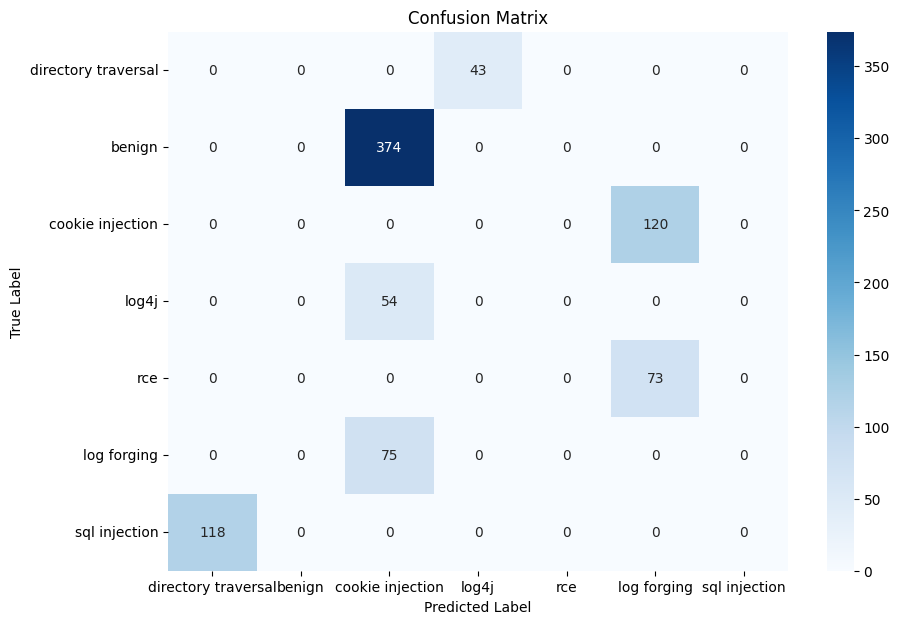

Classification Report:
                     precision    recall  f1-score   support

directory traversal       0.00      0.00      0.00      43.0
             benign       0.00      0.00      0.00     374.0
   cookie injection       0.00      0.00      0.00     120.0
              log4j       0.00      0.00      0.00      54.0
                rce       0.00      0.00      0.00      73.0
        log forging       0.00      0.00      0.00      75.0
      sql injection       0.00      0.00      0.00     118.0

           accuracy                           0.00     857.0
          macro avg       0.00      0.00      0.00     857.0
       weighted avg       0.00      0.00      0.00     857.0



C:\Users\PC_LOCAL\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC_LOCAL\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
C:\Users\PC_LOCAL\AppData\Roaming\Python\Python310\site-packages\sklearn\metrics\_classification.py:1509: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capita

In [17]:
import torch
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from torch.nn.functional import softmax
from sklearn.metrics import confusion_matrix, classification_report

# Load custom tokenizer and trained model
vocab_file_path = "./Datasets/vocab.txt"  # Path to your custom vocab file
model_save_path = "./finegrained_coattention_bert_model"  # Path to your trained model directory

# Initialize tokenizer with custom vocabulary
tokenizer = BertTokenizer(vocab_file=vocab_file_path, do_lower_case=False, unk_token='[NAME]', sep_token='[SEP]', pad_token='[PAD]', cls_token='[CLS]', mask_token='[MASK]')

# Load the trained model
model = BertForSequenceClassification.from_pretrained(model_save_path, num_labels=7)
model.eval()  # Set model to evaluation mode

# Define the label-to-class mapping based on train_df's unique labels
label_mapping = {
    0: "directory traversal",
    1: "benign",
    2: "cookie injection",
    3: "log4j",
    4: "rce",
    5: "log forging",
    6: "sql injection",
}

# Reverse mapping for confusion matrix display
reverse_label_mapping = {v: k for k, v in label_mapping.items()}

# Function to predict a label for a single payload
def predict(payload, tokenizer, model, max_len=128):
    """Predict label for a given payload using custom tokenizer."""
    # Tokenize input text
    encoded_input = tokenizer.encode_plus(
        payload,
        add_special_tokens=True,
        max_length=max_len,
        padding="max_length",
        truncation=True,
        return_tensors="pt"
    )

    input_ids = encoded_input["input_ids"]
    attention_mask = encoded_input["attention_mask"]

    # Perform prediction
    with torch.no_grad():
        outputs = model(input_ids=input_ids, attention_mask=attention_mask)
        logits = outputs.logits
        predicted_label = torch.argmax(logits, dim=1).item()

    return predicted_label

# Apply predictions to val_df
def add_predictions_with_probabilities(val_df, tokenizer, model, label_mapping, max_len=128):
    """
    Add predictions, probabilities, and class names to val_df.
    """
    predictions = []
    probabilities = []

    for payload in val_df['payload']:
        # Use the predict function
        predicted_label = predict(payload, tokenizer, model, max_len)

        # Tokenize input text again to get probabilities
        encoded_input = tokenizer.encode_plus(
            payload,
            add_special_tokens=True,
            max_length=max_len,
            padding="max_length",
            truncation=True,
            return_tensors="pt"
        )

        input_ids = encoded_input["input_ids"]
        attention_mask = encoded_input["attention_mask"]

        # Perform probability computation
        with torch.no_grad():
            outputs = model(input_ids=input_ids, attention_mask=attention_mask)
            logits = outputs.logits
            probs = softmax(logits, dim=1)  # Convert logits to probabilities

        predictions.append(predicted_label)
        probabilities.append(probs.squeeze(0).tolist())  # Convert probabilities to a list

    # Add predicted labels and probabilities to the DataFrame
    val_df['predicted_label'] = predictions
    val_df['predicted_class'] = val_df['predicted_label'].map(label_mapping)
    val_df['probabilities'] = probabilities

    return val_df

# Add predictions, probabilities, and class names to val_df
val_df_with_predictions = add_predictions_with_probabilities(val_df, tokenizer, model, label_mapping)

# Save the DataFrame to a CSV file
output_file = "val_predictions_with_probabilities.csv"
val_df_with_predictions.to_csv(output_file, index=False)
print(f"Predictions with probabilities saved to {output_file}")

# **Step to Compute and Display the Confusion Matrix**
# Convert true labels (ground truth) to numeric format
val_df_with_predictions['true_label'] = val_df_with_predictions['label'].map(reverse_label_mapping)

# Compute confusion matrix
conf_matrix = confusion_matrix(val_df_with_predictions['true_label'], val_df_with_predictions['predicted_label'])

# Display confusion matrix using seaborn heatmap
plt.figure(figsize=(10, 7))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=label_mapping.values(), yticklabels=label_mapping.values())
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

# Print classification report for detailed metrics
print("Classification Report:")
print(classification_report(val_df_with_predictions['true_label'], val_df_with_predictions['predicted_label'], target_names=label_mapping.values()))


In [18]:
val_df_with_predictions.head()

,payload,label,predicted_label,predicted_class,probabilities,true_label
0,orders/check/exists/3476,benign,2,cookie injection,"[0.12916024029254913, 0.13864043354988098, 0.2...",1
1,categories/check/number/7664,benign,2,cookie injection,"[0.1215156689286232, 0.1222720667719841, 0.245...",1
2,greet/2401,benign,2,cookie injection,"[0.12275092303752899, 0.11219574511051178, 0.2...",1
3,categories/check/all,log4j,2,cookie injection,"[0.12156190723180771, 0.1163446307182312, 0.24...",3
4,cookielogin,cookie injection,5,log forging,"[0.1046142652630806, 0.16326023638248444, 0.16...",2
